### Feature Engineering = Deriving new features from existing onces

##### For SpaceDebrisRadar.AI using the primary orbital parameters, we get an easy way to derive such features.
-----

We will derive following features with scientific/mathematical methods

1. Orbit height (h) :
- Describes how high a satellite is above Earth.
- Used to identify orbit type
- Higher orbit = Low drag, more stable, less velocity
- Lower orbit = high drag, less stable, higher velocity

Method to derive -> Using Kepler's 3rd law  
$$
a = \left( \frac{\mu \, T^2}{4 \pi^2} \right)^{\frac{1}{3}}
$$

Where:  
- $a$ = semi-major axis (meters)  
- $\mu = 3.986 \times 10^{14} \, \mathrm{m^3/s^2}$ (Earth’s gravitational parameter)  
- $T$ = orbital period in seconds (computed as $T = \frac{86400}{\text{MEAN\_MOTION}}$)

##### So, we will need to derive first : 1. T (orbital perdiod in second)
----
2. Perigee and Apogee :
- Perigee = Closest point from satellite to Earth in its orbit
- Apogee = Farthest point from satellite to Earth in its orbit
- Helps to analyze orbital shape even clearer

Method to derive -> Using semi-major axis a and eccentricity e

Perigee = a × (1 - e)

Apogee = a × (1 + e)

Intuition: e measures how stretched the orbit is; multiplying by a gives the distance from Earth’s center at the closest/farthest points.

----
3. Orbit speed (v) :
- Describes how fast a satellite is moving .
- Nearer the perigee = higher speed
- Nearer the apogee = lower speed

Method to derive -> sing semi-major axis and radius (vis-viva equation)

Formula:

v = v ≈ sqrt(μ / a)

Where:

μ = Earth’s gravitational parameter

a = semi-major axis

----
4. Age since launch (Days) :


- **Definition:** Time elapsed between the satellite’s **launch date** and the **epoch date** of the current observation.
- **Formula (conceptual):**  
  $$\text{Age (days)} = \text{Epoch Date} - \text{Launch Date}$$
- **Why it matters:**  
  - Satellites degrade over time due to **orbital decay**, **space weather**, or **mechanical aging**.  
  - Useful for **anomaly detection** or understanding expected orbital behavior.
- **Units:** Typically **days**, but can also convert to **years** for readability.
- **Prototype use:** Can be added as a **numerical feature** for clustering or ML models.
----
5. Satellite Type

- **Definition:** The **type or sequence of the satellite** within a launch, extracted from the last character of the `OBJECT_ID`.  
- **How it’s extracted:**  
  - `OBJECT_ID` format: `YYYY-NNN[A-Z]`  
    - `YYYY` → launch year  
    - `NNN` → launch number of that year  
    - `[A-Z]` → satellite type / sequence (A = primary payload, B/C... = secondary payloads)  
- **Why it matters:**  
  - Satellites of the same launch can behave differently; primary payloads may have **different orbit characteristics** than secondary or experimental satellites.  
  - Useful as a **categorical feature** for clustering or anomaly detection.  
- **Prototype use:** Can be added as a **categorical feature** to help ML models distinguish satellite roles within the same launch.


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Important thorughout this project
%matplotlib inline


In [75]:
df = pd.read_csv('../data/02_cleaned/satellites_cleaned.csv')

In [76]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2025-11-24T00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,0,U,900,999,4320,0.000861,8.510000e-06,0.0
1,CALSPHERE 2,1964-063E,2025-11-23T19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,0,U,902,999,82849,0.000074,5.800000e-07,0.0
2,LCS 1,1965-034C,2025-11-23T23:38:09.501216,9.893093,0.001337,32.1445,304.2527,115.9378,244.2499,0,U,1361,999,18956,0.000832,1.500000e-07,0.0
3,TEMPSAT 1,1965-065E,2025-11-23T16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,0,U,1512,999,93266,0.000132,7.500000e-07,0.0
4,CALSPHERE 4A,1965-065H,2025-11-23T22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,0,U,1520,999,93529,0.000215,1.200000e-06,0.0


In [77]:
len(df)

13410

#### 1. Let's compute Orbit height (h) in Kilometers

- Compute orbital period in seconds
- It tells that in average, how much time (in seconds) does a satellite takes to orbit around the Earth

In [78]:
df['ORBIT_PERIOD_SEC'] = 86400 / df['MEAN_MOTION']

In [79]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC
0,CALSPHERE 1,1964-063C,2025-11-24T00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,0,U,900,999,4320,0.000861,8.510000e-06,0.0,6277.560908
1,CALSPHERE 2,1964-063E,2025-11-23T19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,0,U,902,999,82849,0.000074,5.800000e-07,0.0,6386.372286
2,LCS 1,1965-034C,2025-11-23T23:38:09.501216,9.893093,0.001337,32.1445,304.2527,115.9378,244.2499,0,U,1361,999,18956,0.000832,1.500000e-07,0.0,8733.365697
3,TEMPSAT 1,1965-065E,2025-11-23T16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,0,U,1512,999,93266,0.000132,7.500000e-07,0.0,6478.801456
4,CALSPHERE 4A,1965-065H,2025-11-23T22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,0,U,1520,999,93529,0.000215,1.200000e-06,0.0,6465.932675


 - Compute Earth’s gravitational parameter

In [80]:
# Gravitational constant (G) in N m^2/kg^2
G = 6.67430e-11 

# Mass of Earth (M_E) in kg
M_earth = 5.972e24 

# Calculate Earth's gravitational parameter in m^3/s^2
mu_earth_calculated = G * M_earth  # in meters

In [81]:
mu_earth_calculated

398589196000000.0

- Compute Semi major axis for each satelite (in KM)

In [82]:
df['SEMI_MAJOR_AXIS'] = ((mu_earth_calculated * df['ORBIT_PERIOD_SEC'] ** 2 ) / (4*math.pi**2)) **(1/3) / 1000

In [83]:
df['SEMI_MAJOR_AXIS']

0         7354.997884
1         7439.745563
2         9165.926266
3         7511.356523
4         7501.406738
             ...     
13405     6897.027922
13406     6897.756161
13407     6898.521060
13408     6851.050124
13409    26528.725420
Name: SEMI_MAJOR_AXIS, Length: 13410, dtype: float64

- Lastly, subtract semi mejor axis with Earth's radius to get orbital height (h)

In [84]:
df['ORBIT_HEIGHT'] = df['SEMI_MAJOR_AXIS'] -  6371

In [85]:
df['ORBIT_HEIGHT']

0          983.997884
1         1068.745563
2         2794.926266
3         1140.356523
4         1130.406738
             ...     
13405      526.027922
13406      526.756161
13407      527.521060
13408      480.050124
13409    20157.725420
Name: ORBIT_HEIGHT, Length: 13410, dtype: float64

In [86]:
df['ORBIT_HEIGHT'].describe()

count    13410.000000
mean      2457.346065
std       7797.614880
min        151.756209
25%        482.310731
50%        546.818600
75%        579.088758
max      91526.206071
Name: ORBIT_HEIGHT, dtype: float64

#### Since our project is about Low Earth Orbit, we can now easiy filter those satellites (orbital height >=160 & orbtial height <=2000)

In [87]:
# before row count : 
df.shape

(13410, 20)

In [88]:
df = df[(df['ORBIT_HEIGHT'] >=160) & (df['ORBIT_HEIGHT'] <=2000)]

In [89]:
df.shape

(12603, 20)

----
#### 2. Let's compute Perigee and Apogee

In [90]:
# Perigee = a * (1 - e) -> closest point

df['PERIGEE'] = df['SEMI_MAJOR_AXIS'] * (1 - df['ECCENTRICITY']) 

# Apogee = a * (1 + e) -> farthest point

df['APOGEE'] = df['SEMI_MAJOR_AXIS'] * (1 + df['ECCENTRICITY']) 

In [91]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
0,CALSPHERE 1,1964-063C,2025-11-24T00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,0,...,999,4320,0.000861,8.510000e-06,0.0,6277.560908,7354.997884,983.997884,7335.654239,7374.341528
1,CALSPHERE 2,1964-063E,2025-11-23T19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,0,...,999,82849,0.000074,5.800000e-07,0.0,6386.372286,7439.745563,1068.745563,7424.457630,7455.033496
3,TEMPSAT 1,1965-065E,2025-11-23T16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,0,...,999,93266,0.000132,7.500000e-07,0.0,6478.801456,7511.356523,1140.356523,7457.747972,7564.965075
4,CALSPHERE 4A,1965-065H,2025-11-23T22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,0,...,999,93529,0.000215,1.200000e-06,0.0,6465.932675,7501.406738,1130.406738,7449.927584,7552.885891
5,OPS 5712 (P/L 160),1967-053A,2025-11-23T23:24:19.305216,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,0,...,999,3595,0.001312,8.522000e-05,0.0,5862.570613,7027.173125,656.173125,7023.839434,7030.506815


----
#### 3. Let's compute Orbit speed (v)

In [92]:
# Since we can see that the Eccentricity for LEO satellites is barly big (max 0.1), v ≈ sqrt(μ / a) is enough to calcualte the
# orbital speed (which might be mostly / should be constant enough throughout the orbit for each indivisual satellite)
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
count,12603.000000,12603.000000,12603.000000,12603.000000,12603.000000,12603.000000,12603.0,12603.000000,12603.0,12603.000000,12603.000000,1.260300e+04,1.260300e+04,12603.000000,12603.000000,12603.000000,12603.000000,12603.000000
mean,15.014730,0.000527,62.172839,168.155547,160.305446,199.310453,0.0,56921.383242,999.0,13485.943664,0.000088,4.668690e-05,2.728238e-06,5765.152556,6947.579548,576.579548,6943.837363,6951.321732
std,0.618901,0.002942,20.698073,107.331063,91.983381,92.498276,0.0,7477.934341,0.0,13302.728685,0.004462,2.493723e-03,6.037943e-05,262.551598,207.371974,207.371974,205.536360,211.476358
min,11.826701,0.000006,0.047500,0.009600,0.106300,0.099700,0.0,900.000000,999.0,1.000000,-0.155460,-2.582065e-02,-3.856700e-07,5256.080267,6533.761155,162.761155,6532.290405,6535.231904
25%,15.025317,0.000127,43.005950,67.620400,87.492950,97.759900,0.0,52861.500000,999.0,4259.500000,0.000019,3.500000e-07,0.000000e+00,5646.336858,6853.300658,482.300658,6852.409106,6854.234404
50%,15.088436,0.000158,53.160400,164.267400,109.568200,248.735400,0.0,58331.000000,999.0,10862.000000,0.000143,1.517000e-05,0.000000e+00,5726.239740,6917.804424,546.804424,6916.669289,6918.729479
75%,15.301956,0.000283,86.407800,263.991500,262.345900,272.640250,0.0,62930.500000,999.0,18506.000000,0.000686,1.699950e-04,0.000000e+00,5750.294523,6937.164423,566.164423,6936.387710,6938.183866
max,16.438105,0.165136,139.339000,359.848200,359.971400,359.997000,0.0,66554.000000,999.0,99912.000000,0.101830,1.105429e-01,3.356200e-03,7305.503321,8137.456694,1766.456694,8123.186850,9261.182212


In [93]:
# Constants
mu_earth = 3.986e5  # km^3/s^2
R_earth = 6371  # km


# Orbital speed (km/s)
df['ORBITAL_SPEED'] = np.sqrt(mu_earth / df['SEMI_MAJOR_AXIS'])

In [94]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-11-24T00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,0,...,4320,0.000861,8.510000e-06,0.0,6277.560908,7354.997884,983.997884,7335.654239,7374.341528,7.361687
1,CALSPHERE 2,1964-063E,2025-11-23T19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,0,...,82849,0.000074,5.800000e-07,0.0,6386.372286,7439.745563,1068.745563,7424.457630,7455.033496,7.319638
3,TEMPSAT 1,1965-065E,2025-11-23T16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,0,...,93266,0.000132,7.500000e-07,0.0,6478.801456,7511.356523,1140.356523,7457.747972,7564.965075,7.284663
4,CALSPHERE 4A,1965-065H,2025-11-23T22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,0,...,93529,0.000215,1.200000e-06,0.0,6465.932675,7501.406738,1130.406738,7449.927584,7552.885891,7.289492
5,OPS 5712 (P/L 160),1967-053A,2025-11-23T23:24:19.305216,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,0,...,3595,0.001312,8.522000e-05,0.0,5862.570613,7027.173125,656.173125,7023.839434,7030.506815,7.531445


In [95]:
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
count,12603.000000,12603.000000,12603.000000,12603.000000,12603.000000,12603.000000,12603.0,12603.000000,12603.0,12603.000000,12603.000000,1.260300e+04,1.260300e+04,12603.000000,12603.000000,12603.000000,12603.000000,12603.000000,12603.000000
mean,15.014730,0.000527,62.172839,168.155547,160.305446,199.310453,0.0,56921.383242,999.0,13485.943664,0.000088,4.668690e-05,2.728238e-06,5765.152556,6947.579548,576.579548,6943.837363,6951.321732,7.576857
std,0.618901,0.002942,20.698073,107.331063,91.983381,92.498276,0.0,7477.934341,0.0,13302.728685,0.004462,2.493723e-03,6.037943e-05,262.551598,207.371974,207.371974,205.536360,211.476358,0.107549
min,11.826701,0.000006,0.047500,0.009600,0.106300,0.099700,0.0,900.000000,999.0,1.000000,-0.155460,-2.582065e-02,-3.856700e-07,5256.080267,6533.761155,162.761155,6532.290405,6535.231904,6.998812
25%,15.025317,0.000127,43.005950,67.620400,87.492950,97.759900,0.0,52861.500000,999.0,4259.500000,0.000019,3.500000e-07,0.000000e+00,5646.336858,6853.300658,482.300658,6852.409106,6854.234404,7.580147
50%,15.088436,0.000158,53.160400,164.267400,109.568200,248.735400,0.0,58331.000000,999.0,10862.000000,0.000143,1.517000e-05,0.000000e+00,5726.239740,6917.804424,546.804424,6916.669289,6918.729479,7.590747
75%,15.301956,0.000283,86.407800,263.991500,262.345900,272.640250,0.0,62930.500000,999.0,18506.000000,0.000686,1.699950e-04,0.000000e+00,5750.294523,6937.164423,566.164423,6936.387710,6938.183866,7.626386
max,16.438105,0.165136,139.339000,359.848200,359.971400,359.997000,0.0,66554.000000,999.0,99912.000000,0.101830,1.105429e-01,3.356200e-03,7305.503321,8137.456694,1766.456694,8123.186850,9261.182212,7.810647


In [96]:
df[df['ORBIT_HEIGHT'] == df['ORBIT_HEIGHT'].max()]

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
378,GLOBALSTAR M077,2010-054D,2025-11-24T00:02:13.467264,11.826701,0.001754,52.012,341.173,297.5124,98.2805,0,...,69714,0.000031,-8.000000e-07,0.0,7305.503321,8137.456694,1766.456694,8123.18685,8151.726538,6.998812


----
#### 4. Let's find approximate age since launch

In [97]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-11-24T00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,0,...,4320,0.000861,8.510000e-06,0.0,6277.560908,7354.997884,983.997884,7335.654239,7374.341528,7.361687
1,CALSPHERE 2,1964-063E,2025-11-23T19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,0,...,82849,0.000074,5.800000e-07,0.0,6386.372286,7439.745563,1068.745563,7424.457630,7455.033496,7.319638
3,TEMPSAT 1,1965-065E,2025-11-23T16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,0,...,93266,0.000132,7.500000e-07,0.0,6478.801456,7511.356523,1140.356523,7457.747972,7564.965075,7.284663
4,CALSPHERE 4A,1965-065H,2025-11-23T22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,0,...,93529,0.000215,1.200000e-06,0.0,6465.932675,7501.406738,1130.406738,7449.927584,7552.885891,7.289492
5,OPS 5712 (P/L 160),1967-053A,2025-11-23T23:24:19.305216,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,0,...,3595,0.001312,8.522000e-05,0.0,5862.570613,7027.173125,656.173125,7023.839434,7030.506815,7.531445


In [98]:
# Convert Epoch to pandas DateTime object
df['EPOCH'] = pd.to_datetime(df['EPOCH'])


df['AGE_SINCE_LAUNCH'] = round(
    df['EPOCH'].dt.year + df['EPOCH'].dt.dayofyear / 365.25 - df['OBJECT_ID'].str.split('-').str[0].astype(int), 3
)

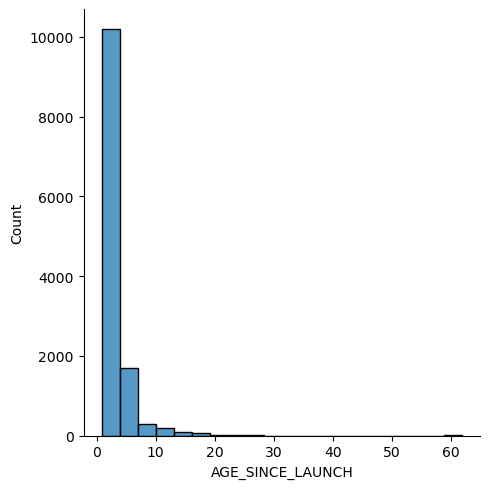

In [99]:
sns.displot(data=df, x = 'AGE_SINCE_LAUNCH', bins = 20)

In [100]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH
0,CALSPHERE 1,1964-063C,2025-11-24 00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,0,...,0.000861,8.510000e-06,0.0,6277.560908,7354.997884,983.997884,7335.654239,7374.341528,7.361687,61.898
1,CALSPHERE 2,1964-063E,2025-11-23 19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,0,...,0.000074,5.800000e-07,0.0,6386.372286,7439.745563,1068.745563,7424.457630,7455.033496,7.319638,61.895
3,TEMPSAT 1,1965-065E,2025-11-23 16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,0,...,0.000132,7.500000e-07,0.0,6478.801456,7511.356523,1140.356523,7457.747972,7564.965075,7.284663,60.895
4,CALSPHERE 4A,1965-065H,2025-11-23 22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,0,...,0.000215,1.200000e-06,0.0,6465.932675,7501.406738,1130.406738,7449.927584,7552.885891,7.289492,60.895
5,OPS 5712 (P/L 160),1967-053A,2025-11-23 23:24:19.305216,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,0,...,0.001312,8.522000e-05,0.0,5862.570613,7027.173125,656.173125,7023.839434,7030.506815,7.531445,58.895


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12603 entries, 0 to 13408
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   OBJECT_NAME          12603 non-null  object        
 1   OBJECT_ID            12603 non-null  object        
 2   EPOCH                12603 non-null  datetime64[ns]
 3   MEAN_MOTION          12603 non-null  float64       
 4   ECCENTRICITY         12603 non-null  float64       
 5   INCLINATION          12603 non-null  float64       
 6   RA_OF_ASC_NODE       12603 non-null  float64       
 7   ARG_OF_PERICENTER    12603 non-null  float64       
 8   MEAN_ANOMALY         12603 non-null  float64       
 9   EPHEMERIS_TYPE       12603 non-null  int64         
 10  CLASSIFICATION_TYPE  12603 non-null  object        
 11  NORAD_CAT_ID         12603 non-null  int64         
 12  ELEMENT_SET_NO       12603 non-null  int64         
 13  REV_AT_EPOCH         12603 non-null 

----
#### 5. Let's find what type of satellite part it it

In [102]:
# This information is stored as the last digit in the OBJECT_ID column
df['OBJECT_ID']

0        1964-063C
1        1964-063E
3        1965-065E
4        1965-065H
5        1967-053A
           ...    
13404    2025-264A
13405    2025-266A
13406    2025-266B
13407    2025-266C
13408    2025-267A
Name: OBJECT_ID, Length: 12603, dtype: object

In [103]:
# capture anything A-Z as a group
df['SAT_TYPE'] = df['OBJECT_ID'].str.extract(r'([A-Z])$')

In [104]:
df['SAT_TYPE'].value_counts()

SAT_TYPE
A    1196
B     874
C     806
D     710
E     659
F     568
G     534
H     530
J     514
K     500
L     480
M     465
N     453
R     438
P     436
Q     435
V     426
S     418
T     416
U     410
W     403
X     363
Y     315
Z     254
Name: count, dtype: int64

In [105]:
df.tail()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE
13404,SENTINEL-6B,2025-264A,2025-11-23 02:27:52.005600,12.858778,0.001154,66.0400,203.5092,270.5110,89.4586,0,...,0.000009,0.0,6719.145255,7695.992135,1324.992135,7687.111960,7704.872309,7.196749,0.895,A
13405,SHIJIAN-30A,2025-266A,2025-11-23 21:30:25.224192,15.156665,0.001287,51.7997,61.1203,289.3668,70.5918,0,...,0.000113,0.0,5700.462372,6897.027922,526.027922,6888.154896,6905.900948,7.602171,0.895,A
13406,SHIJIAN-30B,2025-266B,2025-11-23 18:21:35.472096,15.154265,0.001053,51.7979,61.7429,288.2508,71.7322,0,...,0.000111,0.0,5701.365240,6897.756161,526.756161,6890.490754,6905.021567,7.601770,0.895,B
13407,SHIJIAN-30C,2025-266C,2025-11-23 18:22:38.587296,15.151745,0.001130,51.7989,61.7477,281.2558,78.7148,0,...,0.000090,0.0,5702.313613,6898.521060,527.521060,6890.722972,6906.319148,7.601349,0.895,C
13408,GLOBAL-33,2025-267A,2025-11-21 14:18:25.536096,15.309497,0.000675,42.0189,178.9818,273.7217,86.2848,0,...,0.000036,0.0,5643.555813,6851.050124,480.050124,6846.425460,6855.674789,7.627638,0.890,A


---
Correliation : (help up to check if according to physics our features are consistent (except anomalies!))

In [106]:
df.corr(numeric_only=True)

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH
MEAN_MOTION,1.000000,-0.132842,-0.364584,-0.038304,0.132028,-0.125102,NaN,0.349151,NaN,-0.311302,-0.004224,0.021647,0.075620,-0.998332,-0.998839,-0.998839,-0.993179,-0.993623,0.999813,-0.298636
ECCENTRICITY,-0.132842,1.000000,0.092430,-0.020339,-0.008060,0.009350,NaN,-0.156401,NaN,0.161380,0.007995,0.013625,-0.000215,0.131916,0.132103,0.132103,0.026742,0.233087,-0.132587,0.196139
INCLINATION,-0.364584,0.092430,1.000000,-0.164048,-0.214582,0.208394,NaN,-0.219862,NaN,0.240366,0.029240,0.030712,-0.002032,0.361098,0.361800,0.361800,0.355684,0.363863,-0.363617,0.224121
RA_OF_ASC_NODE,-0.038304,-0.020339,-0.164048,1.000000,-0.020933,0.018494,NaN,-0.039037,NaN,0.039907,0.017348,-0.010915,0.008281,0.036765,0.037031,0.037031,0.039473,0.034260,-0.037806,0.036951
ARG_OF_PERICENTER,0.132028,-0.008060,-0.214582,-0.020933,1.000000,-0.942038,NaN,0.126719,NaN,-0.115028,0.021925,0.038841,0.032729,-0.133608,-0.133400,-0.133400,-0.133698,-0.131680,0.132641,-0.084104
MEAN_ANOMALY,-0.125102,0.009350,0.208394,0.018494,-0.942038,1.000000,NaN,-0.127783,NaN,0.108886,-0.030112,-0.060916,-0.032024,0.126430,0.126267,0.126267,0.126372,0.124810,-0.125636,0.078840
EPHEMERIS_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NORAD_CAT_ID,0.349151,-0.156401,-0.219862,-0.039037,0.126719,-0.127783,NaN,1.000000,NaN,-0.868202,-0.068862,-0.079477,0.007567,-0.342195,-0.343371,-0.343371,-0.329984,-0.352698,0.346865,-0.861719
ELEMENT_SET_NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REV_AT_EPOCH,-0.311302,0.161380,0.240366,0.039907,-0.115028,0.108886,NaN,-0.868202,NaN,1.000000,0.035044,0.041811,-0.009876,0.303852,0.305085,0.305085,0.290775,0.315719,-0.308811,0.764428


----
###  Remove irrelevent features
- We will now remove those features that will NOT be used in any of the ML models, that are :
1. OBJECT_NAME         
2. OBJECT_ID            
4. EPHEMERIS_TYPE   (all have just a single value : 11990)    
5. CLASSIFICATION_TYPE (all have just a single value : U)

7. ELEMENT_SET_NO  (unique identifier)


In [107]:
df = df.drop(columns=['OBJECT_NAME', 'OBJECT_ID',  'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE',  'ELEMENT_SET_NO'])

#### Save the featured data

In [108]:
df.to_csv('../data/03_engineered/satellites_engineered.csv', index=False)

In [109]:
df.head()

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE
0,2025-11-24 00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,900,4320,0.000861,8.510000e-06,0.0,6277.560908,7354.997884,983.997884,7335.654239,7374.341528,7.361687,61.898,C
1,2025-11-23 19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,902,82849,0.000074,5.800000e-07,0.0,6386.372286,7439.745563,1068.745563,7424.457630,7455.033496,7.319638,61.895,E
3,2025-11-23 16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,1512,93266,0.000132,7.500000e-07,0.0,6478.801456,7511.356523,1140.356523,7457.747972,7564.965075,7.284663,60.895,E
4,2025-11-23 22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,1520,93529,0.000215,1.200000e-06,0.0,6465.932675,7501.406738,1130.406738,7449.927584,7552.885891,7.289492,60.895,H
5,2025-11-23 23:24:19.305216,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,2826,3595,0.001312,8.522000e-05,0.0,5862.570613,7027.173125,656.173125,7023.839434,7030.506815,7.531445,58.895,A
